# Germán Cousillas Martínez

# Ejercicio 1

### Apartado 1

In [1]:
m=0.140
sth=4*m**2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sigma = lambda s: np.sqrt(1-sth/s)
J = lambda s: 2/np.pi + sigma(s)/np.pi*np.log( (sigma(s)-1)/(sigma(s)+1) )

In [5]:
print(J(1+0.1j))
print(J(1-0.1j))

(-0.5587028091517566+0.9236695870768244j)
(-0.5587028091517566-0.9236695870768244j)


### Apartado 2

/tmp/ipykernel_5608/1067616322.py:4: RuntimeWarning: divide by zero encountered in divide
  sigma = lambda s: np.sqrt(1-sth/s)
/tmp/ipykernel_5608/1067616322.py:4: RuntimeWarning: invalid value encountered in divide
  sigma = lambda s: np.sqrt(1-sth/s)
/tmp/ipykernel_5608/1067616322.py:5: RuntimeWarning: invalid value encountered in divide
  J = lambda s: 2/np.pi + sigma(s)/np.pi*np.log( (sigma(s)-1)/(sigma(s)+1) )


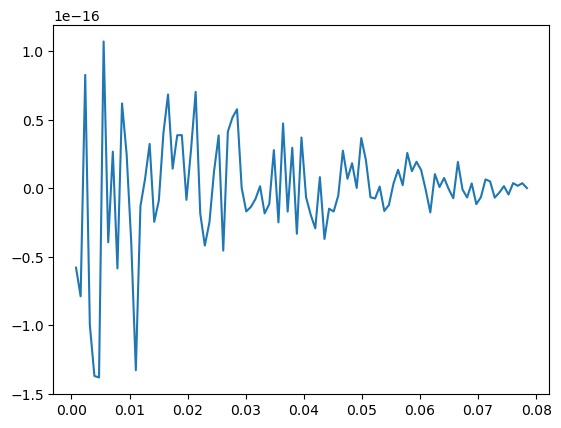

In [6]:
# Representamos parte real e imaginaria (por separado) de J(s)

N=100
s = np.linspace(0,sth, N)

Js = J(s+0.0j)

plt.plot(s, Js.imag)
plt.show()

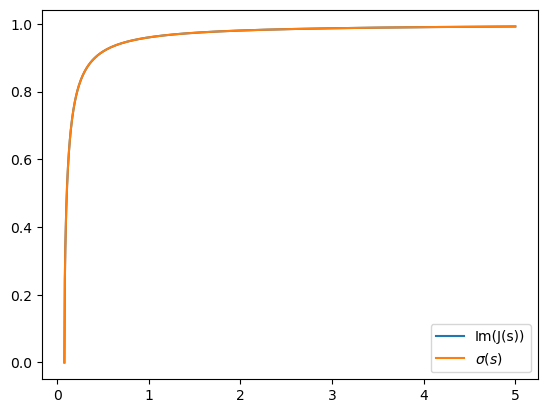

In [7]:
s = np.linspace(sth, 5, 1000)
Js = J(s+0.0j)

plt.plot(s, Js.imag, label="Im(J(s))")
plt.plot(s, sigma(s), label="$\\sigma(s)$")
plt.legend()
plt.show()

## Ejercicio 2

### Apartado 1

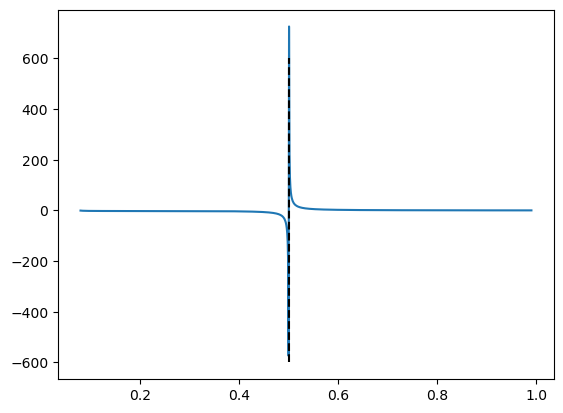

In [34]:
s=0.5
f = lambda sp: s/np.pi * sigma(sp)/sp/(sp-s)

sp = np.linspace(sth*1.01, 0.99, 1000)
plt.plot(sp, f(sp))
plt.vlines(s, -600,600, "k", linestyles="dashed")
plt.show()

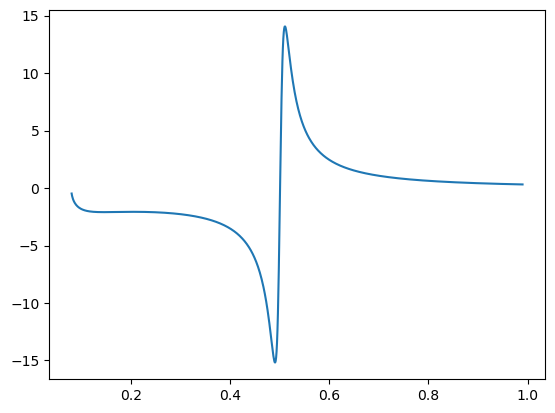

In [38]:
# Representamos parte real del integrando para s=0.5+0.01i
s=0.5+0.01j

sp = np.linspace(sth*1.01, 0.99, 1000)

plt.plot(sp, f(sp).real)
plt.show()

### Apartado 2

In [8]:
import numpy as np
from gaussxw import gaussxwab

N=10000
z, w = gaussxwab(N,0,1)

def Jp(s):
    f = lambda sp: s/np.pi * sigma(sp)/sp/(sp-s)
    g = lambda z: 1/(1-z)**2 * f(z/(1-z)+sth)

    return np.sum(w*g(z))

In [14]:
def romb(a, b, f, tol):
    N=1
    n=1
    h=b/N
    R1m = np.empty(N, complex)
    R1m[0] = h/2*(f(a)+f(b))
    
    err=1.0

    while err > tol:
        N*=2
        h/=2
        n+=1
        R2m = np.empty(n, complex)
        # Calculo el primer elemento con el número de cajas que me indique el primer índice
        R2m[0]= R1m[0]/2 + h*np.sum([f(a+k*h) for k in range(1,N,2)])
        for m in range(1,n):
            eps = 1/(4**m-1)*(R2m[m-1]-R1m[m-1])
            R2m[m]=R2m[m-1] + eps
        err = np.abs(eps)
        R1m = R2m
    return R2m[-1]

In [10]:
def Jp(s):
    f = lambda sp: s/np.pi * sigma(sp)/sp/(sp-s)
    g = lambda z: 1/(1-z)**2 * f(z/(1-z)+sth)

    return romb(0,0.99,g,1e-9)

In [11]:
print(Jp(0.5+0.001j))
print(J(0.5+0.001j))

(-0.28755453422557975+0.9173510509723782j)
(-0.2859113308900251+0.9174514413263667j)


### Apartado 3

In [16]:
def ReJ(s):
    eps=1e-5
    f = lambda sp: sigma(sp)/(sp*(sp-s))
    g = lambda z: 1/(1-z)**2 * f(z/(1-z)+s+eps)
    
    I1 = romb(sth, s-eps, f, 1e-10)
    I2 = romb(0,0.99,g,1e-10)
    
    return s/np.pi * (I1+I2)

print(ReJ(0.5+0.0j))

print(J(0.5+0.0j).real)

(1.8401067602130443+0j)
-0.2857396373438582


In [3]:
from gaussxw import gaussxw

x, w = gaussxw(10000)

def ReJ(s):
    eps=1e-5
    sigma = lambda sp: np.sqrt(1-sth/sp)
    f = lambda sp: sigma(sp) / (sp*(sp-s))
    
    a=sth
    b=s-eps
    s1 = 1/2*((b-a)*x+(b+a))
    w1 = 1/2*(b-a)*w
    
    I1 = np.sum(w1*f(s1))

    g = lambda z: 1/(1-z)**2 * f(z/(1-z)+s+eps)
    
    a=0
    b=1
    s2 = 1/2*((b-a)*x+(b+a))
    w2 = 1/2*(b-a)*w
    
    I2 = np.sum(w2*g(s2))
    
    return s/np.pi*(I1+I2)
    
ReJ(0.5)

-0.2857290327775981

In [60]:
from random import random

def ReJ(s):
    eps=0.0000000001
    f = lambda sp: sigma(sp)/sp/(sp-s)
    g = lambda z: 1/(1-z)**2 * f(z/(1-z)+s+eps)
    
    N = 100000000
    S1=0
    S2=0
    
    s1 = (s-eps-sth)*np.random.rand(N)+sth
    s2 = np.random.rand(N)
    S1 = np.sum(f(s1))
    S2 = np.sum(g(s2))
    
    I1 = S1*(s-eps-sth)/N
    I2 = S2/N
    
    return s/np.pi * (I1+I2)

print(ReJ(0.5+0.0j))
print(J(0.5+0.0j))

(3.657451222775133+0j)
(-0.2857396373438582+0.9182592226599197j)


## Ejercicio 3

### Apartado 1

In [1]:
m=0.140
sth=4*m**2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sigma = lambda s: np.sqrt(1-sth/s)
Jp = lambda s: 2/np.pi + sigma(s)/np.pi*np.log( (sigma(s)-1)/(sigma(s)+1) )

### Apartado 2

In [3]:
M=0.75
g=0.35

In [4]:
import numpy as np
import matplotlib.pyplot as plt

t = lambda s: g**2/(M**2-s+g**2*Jp(s))

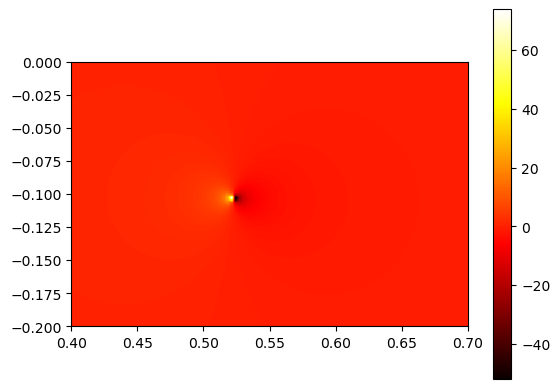

In [9]:
# Generamos región rectangular solicitada en el plano complejo
x = np.linspace(0.4,0.7,100)
y = np.linspace(-0.2,0,100)

X, Y = np.meshgrid(x, y)

Re_t = t(X+1j*Y).real
plt.imshow(Re_t, extent=[0.4,0.7,-0.2,0], cmap="hot", origin="lower")
plt.colorbar()
plt.show()

In [6]:
def punto_fijo(f, x0, tol):
    err = 2*tol
    
    while err > tol:
        x1 = f(x0)
        err = np.linalg.norm(x1-x0)
        x0=x1
        
    return x1

In [7]:
# Buscamos dónde se anula el denominador
f = lambda s: M**2-s+g**2*Jp(s)
h=1e-5

f1 = lambda x, y: np.real(f(x+1j*y))
f2 = lambda x, y: np.imag(f(x+1j*y))

def F(r):
    x, y = r
    return np.array([f1(x, y)+x, f2(x, y)+y], float)

X_polo = punto_fijo(F, [0.5,-0.1], 1e-6)
print(X_polo)

[ 0.52234804 -0.10372553]


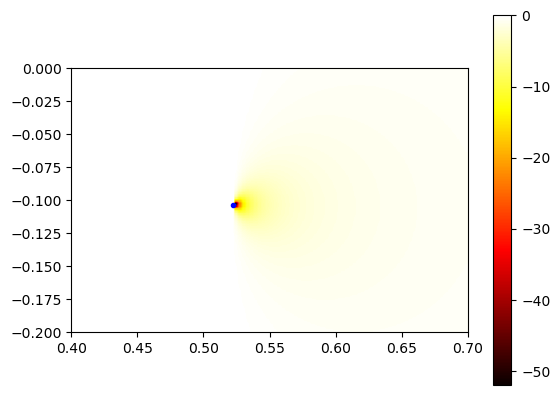

In [8]:
plt.imshow(Re_t, origin="lower", extent=[0.4,0.7,-0.2,0], cmap="hot", vmax=0)
plt.colorbar()
plt.plot(X_polo[0], X_polo[1], "bo", markersize=3)
plt.show()

## Ejercicio 4

In [1]:
R=0.5
m=50
p=1.22
g=9.81
v0=250

### Apartado 1

Procedemos por método del disparo

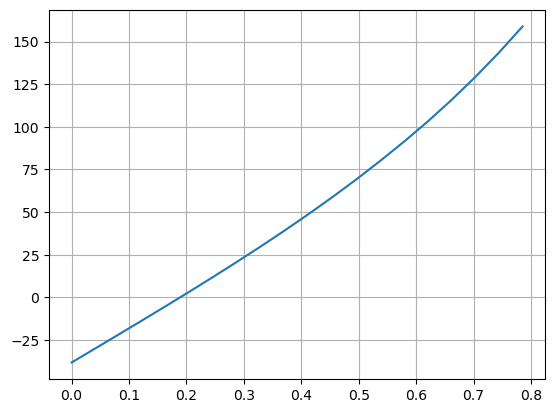

In [2]:
import numpy as np
import matplotlib.pyplot as plt

h=1e-3

def F(r):
    x, y, vx, vy = r
    v = np.sqrt(vx**2+vy**2)
    C = 1/(1+(50*v)**2)
    
    a_x = -np.pi*R**2*p*C/(2*m)*vx*v
    a_y = -g-np.pi*R**2*p*C/(2*m)*vy*v
    
    return np.array([vx, vy, a_x, a_y], float)

def y_200(alpha):
    r = np.array([0,0,v0*np.cos(alpha), v0*np.sin(alpha)], float)
    while r[0] < 200:
        k1 = h*F(r)
        k2 = h*F(r+k1/2)
        k3 = h*F(r+k2/2)
        k4 = h*F(r+k3)
        
        r+=1/6*(k1+2*k2+2*k3+k4)
    return r[1]

y_200 = np.vectorize(y_200)
alpha=np.linspace(0,np.pi/4, 20)

plt.plot(alpha, y_200(alpha)-35)
plt.grid()
plt.show()

In [3]:
def biseccion(f, a, b, tol):
    err = 2*tol
    
    while err > tol:
        x_med = (a+b)/2
        if f(a)*f(x_med)>0: # Estoy en el intervalo de a, me he pasado por la izq. --> recorto a=x_med
            a=x_med
        else:
            b=x_med
        err = np.abs(b-a)
        
    return (b+a)/2

10.822625985181961


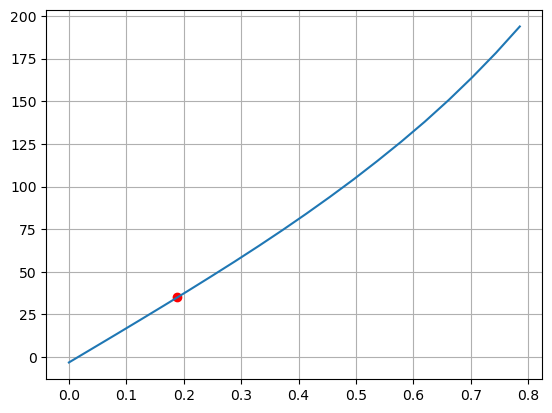

-4.870398135636833e-05


In [5]:
# Ahora buscamos dónde es y=35m
a = 0.1
b = 0.3

f = lambda alpha: y_200(alpha)-35

alpha_opt = biseccion(f, a, b, 1e-6)

print(alpha_opt*180/np.pi)

plt.plot(alpha_opt, y_200(alpha_opt), "ro")
plt.plot(alpha, y_200(alpha))
plt.grid()
plt.show()

### Apartado 2

Para estudiar el rango de ángulos con impacto exitoso, obtenemos el ángulo necesario para alcanzar 33m y 37m en vertical (extremos inferior y superior de la diana)

10.261042367472182
11.372101043531151


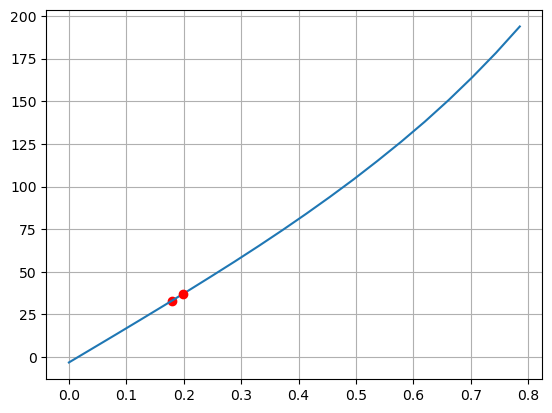

In [6]:
a = 0.1
b = 0.3

f = lambda alpha: y_200(alpha)-33

alpha_min = biseccion(f, a, b, 1e-6)

print(alpha_min*180/np.pi)

plt.plot(alpha_min, y_200(alpha_min), "ro")
plt.plot(alpha, y_200(alpha))
plt.grid()

f = lambda alpha: y_200(alpha)-37

alpha_max = biseccion(f, a, b, 1e-6)

print(alpha_max*180/np.pi)

plt.plot(alpha_max, y_200(alpha_max), "ro")
plt.show()

### Apartado 3

In [7]:
# Trayectorias

# Ángulo mínimo
h=1e-3
r = np.array([0,0,v0*np.cos(alpha_min), v0*np.sin(alpha_min)], float)
xp_min = []
yp_min = []

while r[0] < 200:
    xp_min.append(r[0])
    yp_min.append(r[1])
    
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)

r = np.array([0,0,v0*np.cos(alpha_max), v0*np.sin(alpha_max)], float)
xp_max = []
yp_max = []

while r[0] < 200:
    xp_max.append(r[0])
    yp_max.append(r[1])
    
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)
    
r = np.array([0,0,v0*np.cos(alpha_opt), v0*np.sin(alpha_opt)], float)
xp_opt = []
yp_opt = []

while r[0] < 200:
    xp_opt.append(r[0])
    yp_opt.append(r[1])
    
    k1 = h*F(r)
    k2 = h*F(r+k1/2)
    k3 = h*F(r+k2/2)
    k4 = h*F(r+k3)
    
    r+=1/6*(k1+2*k2+2*k3+k4)

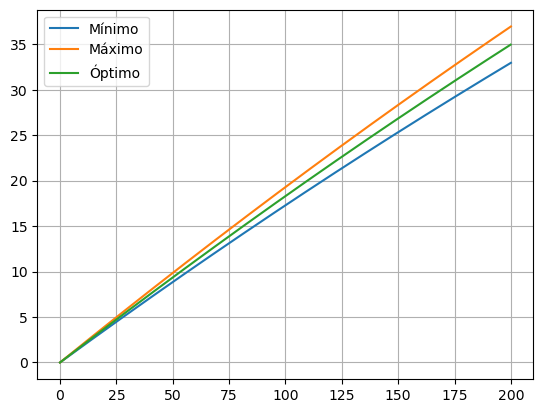

In [8]:
plt.plot(xp_min, yp_min, label="Mínimo")
plt.plot(xp_max, yp_max, label="Máximo")
plt.plot(xp_opt, yp_opt, label="Óptimo")
plt.legend()
plt.grid()
plt.show()